# Table of contents

* **Introduction**
* **Objective**
* **Multi-Layer Perceptron (MLP) Foundations**
* **Data Dictionary**
* **Pipeline Overview**
* **Approach**
* **Setup Environments**
* **Dataset Loading**
* **Exploratory Data Analysis (EDA)**
* **Features Engineering**
* **Model Training and Experiments**
    * Model Architecture, Model Building, and Model Training (PyTorch)
* **Model Evaluation**
* **Conclusion**
* **References**

# Introduction

This document outlines the approach taken to build, train, and evaluate a Multi-Layer Perceptron ($\text{MLP}$) using PyTorch for a challenging binary classification task. The goal is to accurately distinguish between benign (goodware) and malicious ($\text{malware}$) executable files based on time-series sequences of $\text{API}$ calls. The dataset presents a critical real-world obstacle: severe class imbalance, with $\text{malware}$ constituting approximately 97.5% of the samples and goodware just 2.5%. This imbalance necessitates specialized preprocessing and evaluation techniques to ensure the model learns eff

# Objective

The primary goal is twofold: first, to successfully implement a complete deep learning workflow in $\text{PyTorch}$, including data handling and model definition; and second, to develop a classifier that performs robustly despite the extreme class imbalance. This involves implementing a custom $\text{MLP}$, strategically applying resampling techniques to the training data, optimizing with an appropriate loss function and optimizer, and utilizing a comprehensive set of imbalance-aware evaluation metrics to provide an honest assessment of the model's true performance.

# Multi-Layer Perceptron (MLP) Foundations

The Multi-Layer Perceptron ($\text{MLP}$), often referred to as a standard feedforward neural network, is a fundamental architecture in deep learning. Its core concept is the ability to learn complex, non-linear mappings between input data and output targets.

**The Universal Approximation Theorem**

The theoretical power of the $\text{MLP}$ is rooted in the Universal Approximation Theorem. This theorem states that a feedforward network with a single hidden layer and a non-linear activation function is theoretically capable of approximating any continuous function to an arbitrary level of accuracy, provided it has a sufficient number of neurons. This capability allows the $\text{MLP}$ to solve non-linearly separable problems, unlike simpler models such as the Perceptron.

**Learning Mechanism**

The $\text{MLP}$ learns through a two-step process:

- Forward Propagation: Input data moves through the network, from the input layer to the output layer, where a prediction is generated.
- Backpropagation: The error (the difference between the prediction and the true target) is calculated. This error is then propagated backward through the network, layer by layer. This process uses the chain rule of calculus to determine the gradient of the loss function with respect to every single weight in the network. These gradients indicate the direction and magnitude by which the weights must be adjusted.
- Optimization: An optimization algorithm (like $\text{SGD}$ or $\text{Adam}$) uses these gradients to update the weights, iteratively minimizing the overall error.

**MLP Composition and Structure**

The $\text{MLP}$ is organized into a minimum of three distinct types of layers:

**1. The Input Layer**

This layer receives the raw data features. It does not perform any computation; its nodes simply represent the input variables, passing the feature values directly to the next layer. The number of neurons in the input layer is always equal to the number of features in the dataset ($\mathbf{N_{features}}$).

**2. Hidden Layers**

These are the computational engine of the network, positioned between the input and output layers. A network is considered "deep" when it contains multiple hidden layers.

- Synaptic Connections (Weights): Each neuron in a hidden layer is connected to every neuron in the preceding layer. Each connection has an associated weight ($\mathbf{W}$), which is a trainable parameter that determines the strength of the connection.
- Bias: Each neuron also has a bias ($\mathbf{b}$), another trainable parameter that allows the activation function to be shifted, providing flexibility in the model's ability to fit the data.
- Activation Function: After the linear combination of weighted inputs and bias ($\mathbf{Z} = \mathbf{W} \cdot \mathbf{X} + \mathbf{b}$), the result is passed through a non-linear activation function (e.g., $\text{ReLU}$, $\text{Sigmoid}$, or $\text{Tanh}$). This non-linearity is essential for the $\text{MLP}$ to learn complex relationships and avoid simply collapsing into a linear model.

**3. The Output Layer**

This final layer produces the network's prediction. The number of neurons and the choice of activation function depend directly on the type of task:
- Binary Classification (e.g., malware vs. benign): Typically uses one neuron with a $\text{Sigmoid}$ activation, which outputs a probability between 0 and 1.
- Multi-class Classification (e.g., classifying images into 10 categories): Uses $N$ neurons (where $N$ is the number of classes) with a $\text{Softmax}$ activation, which converts the raw outputs into a probability distribution summing to 1.
- Regression (e.g., predicting house prices): Typically uses one neuron with no activation function (or a linear activation).

# Data Dictionary

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-za14">Column Name</th>
    <th class="tg-7zrl">Description</th>
    <th class="tg-7zrl">Data Type</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">hash</td>
    <td class="tg-7zrl">Unique identifier for each record</td>
    <td class="tg-7zrl">Alphanumeric</td>
  </tr>
  <tr>
    <td class="tg-7zrl">t_0 - t_99</td>
    <td class="tg-7zrl">Time series measurement at index 0-99</td>
    <td class="tg-7zrl">Numerical (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">malware</td>
    <td class="tg-7zrl">Goodware (0) and Malware (1)</td>
    <td class="tg-7zrl">Categorical (Class)</td>
  </tr>
</tbody>
</table>

**[Dataset Link](https://www.kaggle.com/datasets/mirichoi0218/insurance)**

# Pipeline Overview

The entire end-to-end classification workflow is structured into four sequential and critical stages:
- Data Loading & Exploration: Initial data ingestion and analysis to understand the dataset.
- Preprocessing Pipeline: Preparing the raw, high-dimensional data for neural network consumption. This stage includes feature engineering, scaling, dimensionality reduction using $\mathbf{PCA}$, and crucial class balancing via $\mathbf{SMOTE}$.
- Model Definition & Training: Implementing the $\text{MLP}$ architecture in $\text{PyTorch}$, defining the training loop, selecting the $\mathbf{BCELoss}$ and $\mathbf{Adam}$ optimizer, and employing early stopping based on validation performance.
- Model Evaluation & Interpretation: Assessing the trained model using a full suite of metrics—including $\mathbf{Precision}$, $\mathbf{Recall}$, and $\mathbf{AUC-ROC}$—to determine its practical effectiveness, especially on the minority class.

# Approach

**Preprocessing Pipeline Approach**

The preprocessing steps are applied to transform the raw, high-dimensional, and imbalanced sequential data for optimal neural network stability and training fairness:
- Initial Cleanup and Splitting: Non-informative identifier columns (the hash) are removed. A stratified $80%$-$20%$ split of the dataset is performed immediately to separate the test set, guaranteeing that the class proportions are maintained in both partitions and preventing information leakage into the training phase.
- Standardization: The StandardScaler technique is applied to scale the $100$ features. This ensures all input features have a zero mean and unit variance, which is essential for the stable and efficient convergence of the $\text{MLP}$'s gradient descent optimizer.
- Dimensionality Reduction: Principal Component Analysis ($\text{PCA}$) is utilized to reduce the feature space from $100$ dimensions down to just $2$ components. This reduction serves the dual purpose of mitigating noise and providing a $2\text{D}$ projection, which is necessary for visualizing the model's decision boundary.
- Class Imbalance Correction: The Synthetic Minority Over-sampling Technique ($\text{SMOTE}$) is applied exclusively to the training set (post-$\text{PCA}$). $\text{SMOTE}$ synthesizes minority class samples (benign) to create a balanced $50%$-$50%$ distribution, which ensures the neural network learns robust features for both classes rather than simply predicting the majority class.

**Model Training Approach**

The training phase is executed within the PyTorch framework, defining the network and its learning parameters precisely:
- Model Implementation: A custom `nn.Module` class is defined for the $\text{MLP}$ architecture. The network consists of an input layer of size $2$, two hidden layers of $64$ neurons each using the $\text{ReLU}$ activation function, and a final output layer of size $1$ using the $\text{Sigmoid}$ activation function to produce a probability for binary classification.
- Core Components: The Binary Cross-Entropy Loss (`BCELoss`) is selected as the objective function, appropriate for binary probability output. The $\text{Adam}$ optimizer is chosen for its efficient and adaptive learning rate updates, initialized with a learning rate of $0.0001$.
- Training Regime: The training data is further subdivided to allocate $20%$ as an internal validation set. Training is executed up to a maximum of $100$ epochs using full-batch gradient descent. Early stopping is implemented with a patience of $5$ epochs; this technique monitors the validation loss and halts training when generalization performance ceases to improve, automatically restoring the weights corresponding to the best observed validation loss.

**Model Evaluation Approach**

A comprehensive evaluation suite is employed, prioritizing metrics and visualizations that provide true insight into performance on the imbalanced dataset:
- Quantitative Metrics: Evaluation is based on $\text{Accuracy}$, $\text{AUC-ROC}$, and the macro-averaged values of $\text{Precision}$, $\text{Recall}$, and $\text{F1}$-score. Macro-averaging is essential as it treats performance on the rare benign class equally to the majority malware class.
- Diagnostic Tools: The Confusion Matrix is computed to explicitly quantify the number of true and false predictions for each class. Precision-Recall curves and $\text{ROC}$ curves are plotted to visualize the model's performance trade-offs across various classification thresholds.
- Visualization: The model's non-linear decision boundary is plotted in the $2\text{D}$ $\text{PCA}$ space for both the training and test sets. This visualization is crucial for visually interpreting the complex separation learned by the $\text{MLP}$ and assessing its generalization capability to unseen samples.

# Setup Environments

**Package Installation**

In [ ]:
%%capture
!pip install imblearn
!pip install imbalanced-learn==0.10.1
!pip install --upgrade imbalanced-learn

**Import Libraries**

In [ ]:
import numpy as np
import pylab as pl
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
import os
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_classification 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    auc,
    roc_curve
)

print(f"PyTorch Version: {torch.__version__}")

# Dataset Loading

The pipeline began by loading the dataset, which consists of dynamic API call sequences from various malware samples. This data structure represents a critical security feature, where the sequence of functions called by a program provides a behavioral fingerprint for classification. Each row corresponds to a single malware sample, identified by a unique hash (subsequently dropped), and the features t_0 through t_99 represent the ordered sequence of 100 API calls. The target variable, malware, is a binary label indicating the presence (1) or absence (0) of malicious code.

In [ ]:
df = pd.read_csv('/kaggle/input/malware-analysis-datasets-api-call-sequences/dynamic_api_call_sequence_per_malware_100_0_306.csv')
df.head()

,hash,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,...,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99,malware
0,071e8c3f8922e186e57548cd4c703a5d,112,274,158,215,274,158,215,298,76,...,71,297,135,171,215,35,208,56,71,1
1,33f8e6d08a6aae939f25a8e0d63dd523,82,208,187,208,172,117,172,117,172,...,81,240,117,71,297,135,171,215,35,1
2,b68abd064e975e1c6d5f25e748663076,16,110,240,117,240,117,240,117,240,...,65,112,123,65,112,123,65,113,112,1
3,72049be7bd30ea61297ea624ae198067,82,208,187,208,172,117,172,117,172,...,208,302,208,302,187,208,302,228,302,1
4,c9b3700a77facf29172f32df6bc77f48,82,240,117,240,117,240,117,240,117,...,209,260,40,209,260,141,260,141,260,1


**Initial Data Preocessing**

The initial preprocessing involved two standard steps:

- Feature Reduction: The hash column was dropped as it serves only as an identifier and contributes no predictive power to the classification model.
- Missing Value Handling: Any rows containing missing values (NaN) were removed using the dropna(how='any') function. This process ensures the resulting dataset is clean and ready for machine learning.

In [21]:
df = df.drop(columns=['hash'],axis=1)
df = df.dropna(how='any')
df

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99,malware
0,112,274,158,215,274,158,215,298,76,208,...,71,297,135,171,215,35,208,56,71,1
1,82,208,187,208,172,117,172,117,172,117,...,81,240,117,71,297,135,171,215,35,1
2,16,110,240,117,240,117,240,117,240,117,...,65,112,123,65,112,123,65,113,112,1
3,82,208,187,208,172,117,172,117,172,117,...,208,302,208,302,187,208,302,228,302,1
4,82,240,117,240,117,240,117,240,117,172,...,209,260,40,209,260,141,260,141,260,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43871,82,240,117,240,117,240,117,240,117,172,...,141,260,141,260,141,260,141,260,141,1
43872,82,240,117,240,117,240,117,240,117,172,...,159,224,82,159,224,82,159,224,82,1
43873,82,240,117,240,117,240,117,240,117,172,...,260,141,260,141,260,141,260,141,260,1
43874,82,240,117,240,117,240,117,240,117,172,...,141,260,141,260,141,260,141,260,141,1


**Train and Test Split**

Training and testing sets were created using a 80/20 split ratio, which is a common practice in machine learning for model validation. The data was split using the `train_test_split` function with a fixed `random_state` to ensure the split is reproducible.
- Training Set (80%): Used to train the classification model.
- Testing Set (20%): Used to provide an unbiased estimate of the final model's performance on unseen data.

In [ ]:
train, test = train_test_split(df, test_size=0.2, random_state=42) 

print("train shape:", train.shape)
print("test shape:", test.shape)

train shape: (35100, 101)
test shape: (8776, 101)


# Exploratory Data Analysis (EDA)

**Basic information**

**Descriptive Statistics and Imbalance Analysis**

Descriptive statistics (`train.describe()`) confirmed the numerical nature of all feature columns (API call IDs) and showed the feature values range from 0 to 306. Crucially, the analysis of the target variable, malware, revealed a severe class imbalance.
- Malware Class (1): Constitutes approximately 97.57% of the training data.
- Benign Class (0): Constitutes approximately 2.43% of the training data.

In [23]:
train.head()

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99,malware
35602,112,274,158,215,274,158,215,298,76,208,...,71,297,135,171,215,35,208,56,71,1
13858,112,274,158,215,274,158,215,298,76,208,...,172,117,172,117,172,117,172,117,172,1
39770,112,274,158,215,274,158,215,298,76,208,...,71,297,135,171,215,35,208,56,71,1
1024,208,286,76,110,240,117,208,187,208,198,...,286,240,286,117,208,286,240,286,117,1
31154,82,208,187,208,172,117,172,208,16,208,...,117,172,117,208,172,117,100,215,35,1


In [24]:
train.describe()

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99,malware
count,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,...,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000
mean,142.787123,211.254872,148.203333,188.834245,187.417949,174.108063,170.378148,199.045271,142.807322,167.325413,...,154.204786,173.156809,159.560484,164.906980,173.463419,152.373533,158.394758,160.395926,155.748262,0.975698
std,75.600839,60.294950,47.698712,68.358486,71.255625,65.739453,55.525942,65.516243,66.800136,53.441632,...,78.291792,82.742852,74.071577,70.322547,70.531624,79.906061,78.029384,75.022546,78.949398,0.153987
min,2.000000,2.000000,2.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,82.000000,172.000000,117.000000,117.000000,117.000000,117.000000,117.000000,159.000000,117.000000,117.000000,...,81.000000,117.000000,114.000000,117.000000,117.000000,89.000000,100.000000,108.000000,73.000000,1.000000
50%,82.000000,240.000000,158.000000,215.000000,172.000000,158.000000,172.000000,215.000000,117.000000,172.000000,...,141.000000,172.000000,141.000000,171.000000,172.000000,141.000000,171.000000,156.000000,141.000000,1.000000
75%,215.000000,240.000000,172.000000,240.000000,274.000000,240.000000,215.000000,240.000000,208.000000,208.000000,...,240.000000,260.000000,240.000000,215.000000,240.000000,215.000000,224.000000,225.000000,225.000000,1.000000
max,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,...,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,1.000000


In [25]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35100 entries, 35602 to 15795
Columns: 101 entries, t_0 to malware
dtypes: int64(101)
memory usage: 27.3 MB


In [26]:
train.isnull().sum()

t_0        0
t_1        0
t_2        0
t_3        0
t_4        0
          ..
t_96       0
t_97       0
t_98       0
t_99       0
malware    0
Length: 101, dtype: int64

In [27]:
test.isnull().sum()

t_0        0
t_1        0
t_2        0
t_3        0
t_4        0
          ..
t_96       0
t_97       0
t_98       0
t_99       0
malware    0
Length: 101, dtype: int64

**Class Distribution Analysis**

**Class Imbalance**

This imbalanced classification problem must be addressed in subsequent modeling steps (e.g., using techniques like SMOTE or assigning class weights), as a model trained on this skewed data would likely become highly biased towards the majority class (malware) and perform poorly in detecting the minority class (benign).

In [28]:
train['malware'].value_counts(normalize=True)*100

malware
1    97.569801
0     2.430199
Name: proportion, dtype: float64

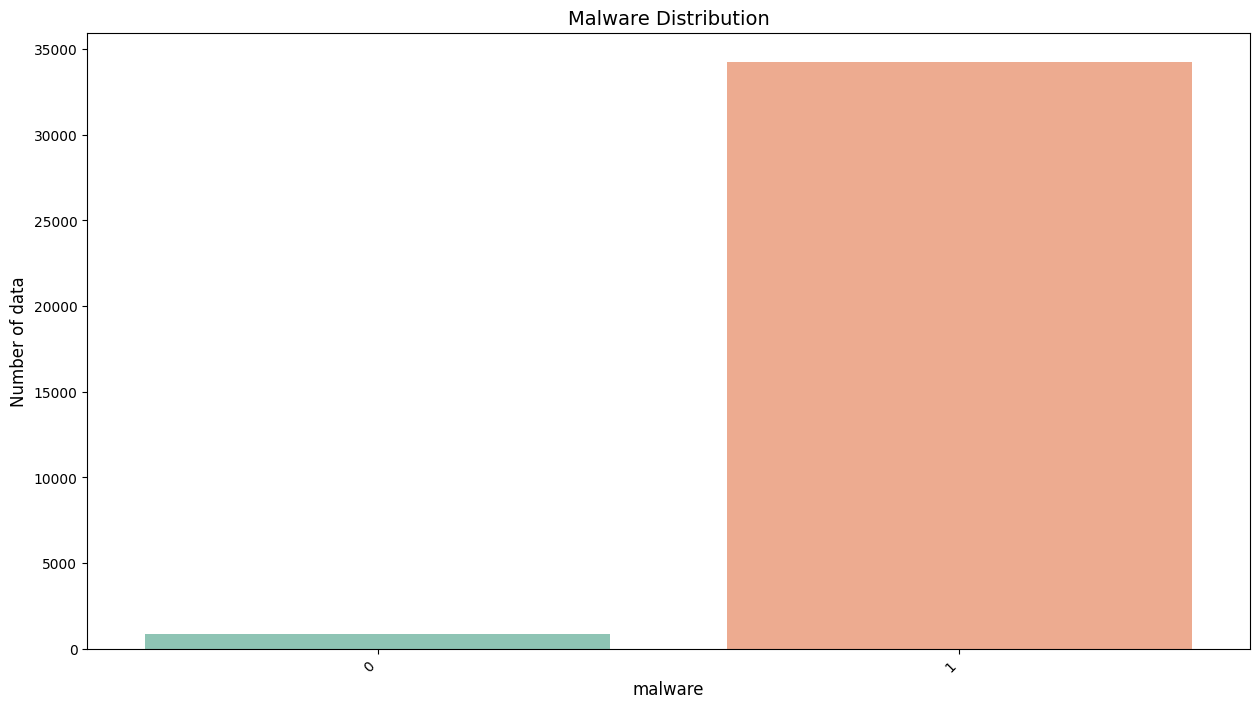

In [ ]:
cnt_pro = train['malware'].value_counts()

plt.figure(figsize=(15,8))
ax = sns.barplot(x=cnt_pro.index, y=cnt_pro.values, alpha=0.8, palette="Set2")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.ylabel('Number of data', fontsize=12)
plt.xlabel('malware', fontsize=12)
plt.title('Malware Distribution', fontsize=14)
plt.show()

**Key Visual Finding**

The Malware Distribution bar plot visually confirms the quantitative findings on class imbalance. The bar representing the Malware (1) class is overwhelmingly dominant, while the bar representing the Benign (0) class is barely visible. This stark visual contrast reinforces the need to prioritize robust evaluation metrics beyond simple accuracy (such as Precision, Recall, and F1-Score) and to apply resampling techniques to mitigate the bias before training a classifier. The model's primary challenge will be to distinguish the small number of benign samples accurately, which is typically the most critical task in real-world anomaly or threat detection systems.

# Features Engineering

The feature engineering phase transforms the raw, standardized data into a format optimized for the machine learning classifier. This process addressed scale variations, excessive dimensionality, and the severe class imbalance inherent in the original dataset.

**Features and Target Labels Split**

The initial step involved partitioning the dataset into the feature matrix ($\mathbf{X}$) and the target vector ($\mathbf{y}$). The 100 API call sequence features, from t_0 to t_99, constituted the predictor set ($\mathbf{X}$), while the binary malware column was isolated as the response variable ($\mathbf{y}$). This separation is fundamental to supervised learning, ensuring the model is trained only on the input features and validated against the known output label.

In [ ]:
x_train = train.drop('malware', axis=1) 
y_train = train['malware'] 
x_test = test.drop('malware', axis=1) 
y_test = test['malware'] 

print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (35100, 100)
y_train shape: (35100,)
X_test shape: (8776, 100)
y_test shape: (8776,)


**Data Normalization (Standardization)**

Standardization was applied using the `StandardScaler` to the feature matrices ($\mathbf{X}_{\text{train}}$ and $\mathbf{X}_{\text{test}}$). Standardization transforms the data such that each feature has a mean of 0 and a standard deviation of 1.This transformation is crucial for several reasons:
- Equal Contribution: It ensures that all 100 API call features contribute equally to the distance calculation in subsequent algorithms, preventing features with larger numerical ranges from dominating the model training process.
- Optimization Stability: Standardization stabilizes the training process for gradient-descent-based models, such as Neural Networks (MLP), by keeping feature values within a manageable, consistent range, thereby accelerating convergence.

In [ ]:
scaler = StandardScaler()

x_train_std = scaler.fit_transform(x_train)
x_test_std = scaler.transform(x_test)

In [ ]:
x_train_std = pd.DataFrame(x_train_std, columns=x_train.columns)
x_test_std = pd.DataFrame(x_test_std, columns=x_test.columns)
x_train_std.describe()

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_90,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99
count,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,...,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04
mean,-1.530400e-16,-1.220676e-16,-2.702492e-16,-1.805710e-16,-1.781418e-17,-6.498126e-17,7.530538e-17,8.502221e-18,-1.064802e-16,2.206529e-17,...,3.623566e-17,1.651860e-16,2.753100e-17,-1.615422e-16,1.595179e-16,2.200456e-16,1.388696e-16,1.046583e-16,2.672127e-17,-2.186285e-17
std,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,...,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00
min,-1.862269e+00,-3.470570e+00,-3.065186e+00,-2.733193e+00,-2.630257e+00,-2.648494e+00,-3.068486e+00,-3.007622e+00,-2.137860e+00,-3.093614e+00,...,-1.988217e+00,-1.969644e+00,-2.092740e+00,-2.154170e+00,-2.345042e+00,-2.459406e+00,-1.906935e+00,-2.029966e+00,-2.138000e+00,-1.972789e+00
25%,-8.040650e-01,-6.510567e-01,-6.541849e-01,-1.050861e+00,-9.882581e-01,-8.687154e-01,-9.613328e-01,-6.112353e-01,-3.863419e-01,-9.417027e-01,...,-5.210352e-01,-9.350384e-01,-6.787004e-01,-6.150960e-01,-6.812561e-01,-8.005519e-01,-7.931117e-01,-7.483795e-01,-6.984123e-01,-1.048133e+00
50%,-8.040650e-01,4.767487e-01,2.053893e-01,3.827780e-01,-2.163783e-01,-2.450323e-01,2.920932e-02,2.435267e-01,-3.863419e-01,8.747213e-02,...,-6.894509e-03,-1.686636e-01,-1.398097e-02,-2.505786e-01,8.664514e-02,-2.074870e-02,-1.423383e-01,1.615471e-01,-5.859557e-02,-1.868092e-01
75%,9.551998e-01,4.767487e-01,4.989025e-01,7.485023e-01,1.215108e+00,1.002334e+00,8.036331e-01,6.251169e-01,9.759502e-01,7.611139e-01,...,1.021387e+00,1.095855e+00,1.049570e+00,1.085986e+00,7.123424e-01,9.433716e-01,7.837623e-01,8.407881e-01,8.611411e-01,8.771786e-01
max,2.158907e+00,1.571383e+00,3.308243e+00,1.714014e+00,1.664202e+00,2.006311e+00,2.442530e+00,1.632515e+00,2.443034e+00,2.594916e+00,...,1.849028e+00,1.938867e+00,1.605517e+00,1.977028e+00,2.006398e+00,1.879135e+00,1.922616e+00,1.891689e+00,1.940832e+00,1.903167e+00


**Dimensionality Reduction (PCA)**

Principal Component Analysis (PCA), a linear dimensionality reduction technique, was employed to compress the 100-dimensional feature space into a significantly smaller, more manageable space. PCA identifies new orthogonal axes, or Principal Components (PCs), that capture the maximum variance in the original data.

In this analysis, the feature space was reduced from 100 dimensions down to two principal components (`n_components=2`). This reduction serves two primary purposes:
- Computational Efficiency: It drastically reduces the number of parameters the classification model must learn, leading to faster training times.
- Visualization: It allows the complex, high-dimensional structure of the API call data to be plotted and inspected in a two-dimensional scatter plot.

In [ ]:
pca = PCA(n_components=2) 
x_train = pca.fit_transform(x_train_std)
x_test = pca.transform(x_test_std)

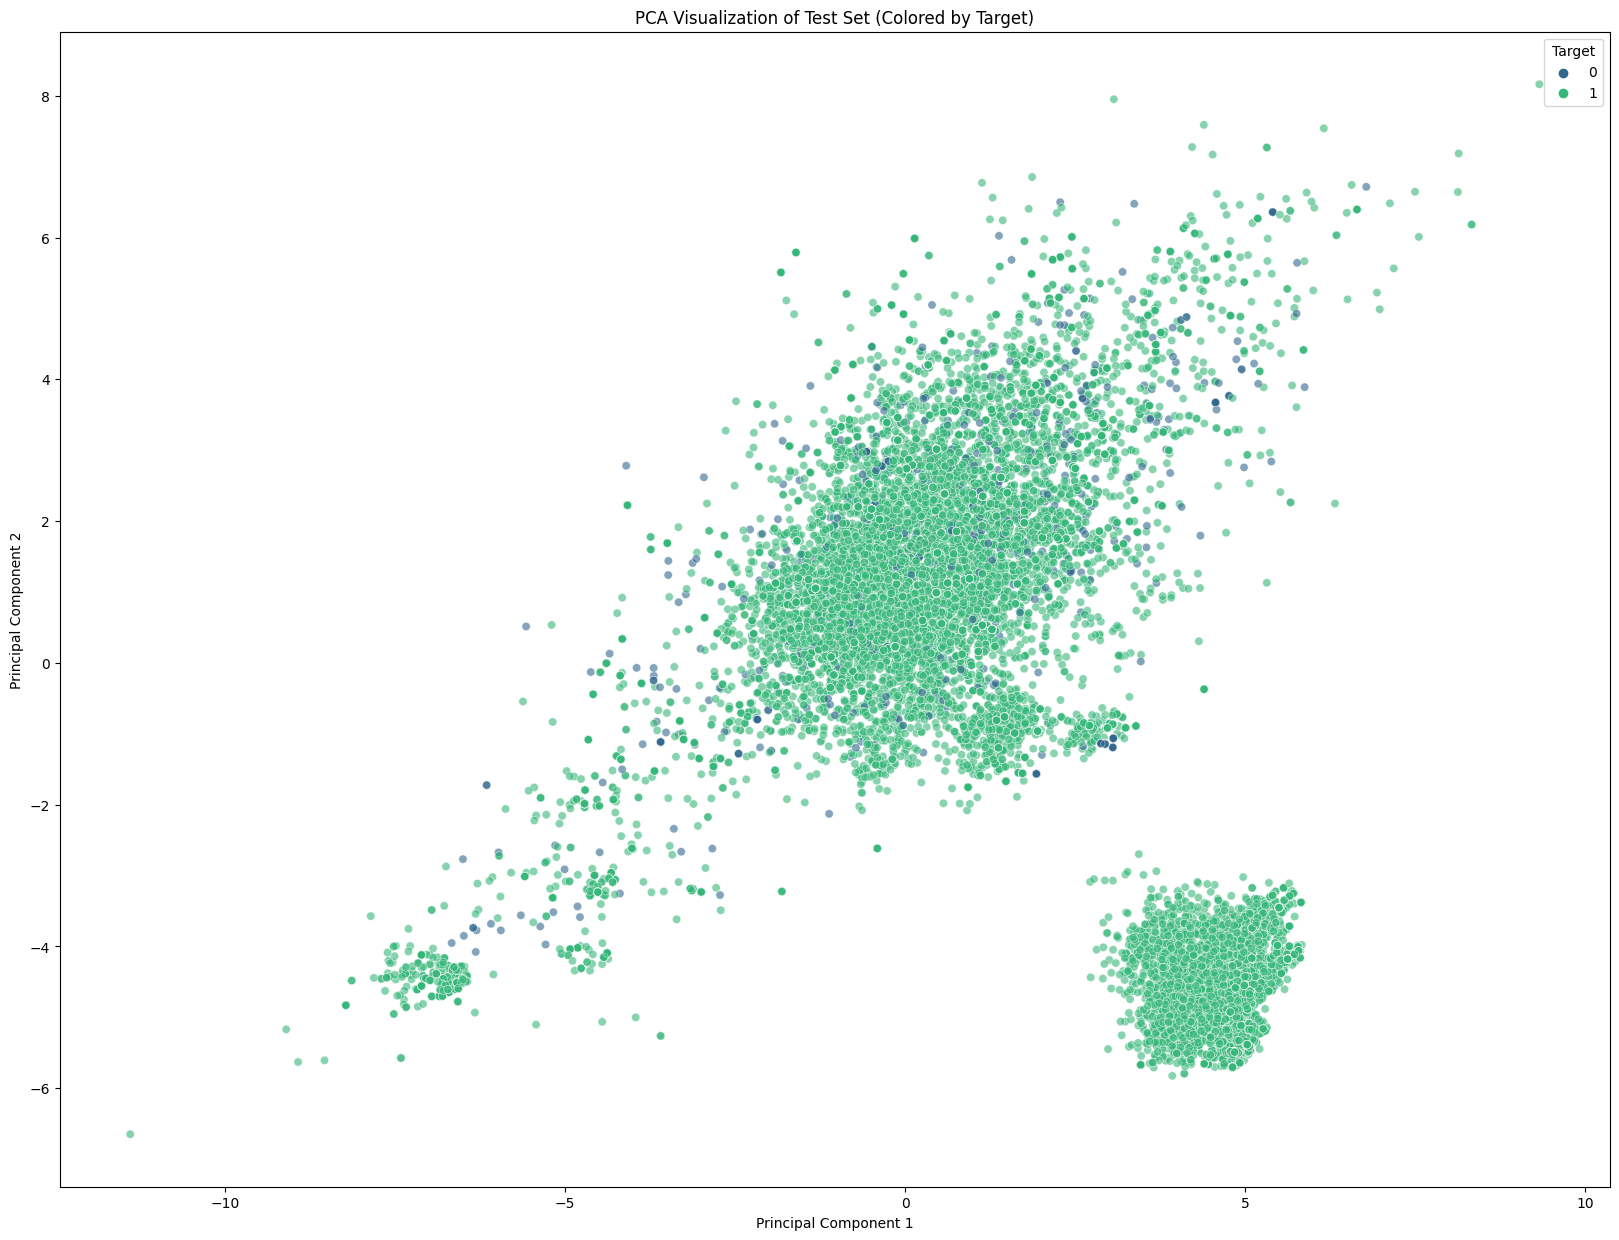

In [ ]:
plot_data = pd.DataFrame({
    'PC1': x_train[:, 0],  
    'PC2': x_train[:, 1],  
    'Target': y_train      
})

plt.figure(figsize=(20, 15))
sns.scatterplot(
    data=plot_data,
    x="PC1",
    y="PC2",
    hue="Target",  
    palette="viridis",  
    alpha=0.6  
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Test Set (Colored by Target)")

plt.show()

**Visualization Interpretation**

Two scatter plots visualize the PCA-transformed training data, colored by the target class, providing a clear illustration of the data characteristics before and after oversampling.

**Visualization Before oversampling**

The initial scatter plot (on the original 35,100 samples) shows an extremely dense, large cluster representing the majority class (Malware), with the minority class (Benign) sparsely distributed around the edges or within the majority cluster. The highly clustered nature of the minority class suggests that, even in the reduced 2D space, the two classes are not easily separable by a simple linear boundary. The scarcity of the minority data points makes accurate model discrimination highly challenging.

**Oversampling (SMOTE)**

Following PCA, the crucial problem of class imbalance (97.57% Malware vs. 2.43% Benign) was addressed using the Synthetic Minority Oversampling Technique (SMOTE).

SMOTE works by synthesizing new, artificial examples for the minority class (`malware=0`). It operates by taking existing minority samples, identifying their nearest neighbors, and generating synthetic samples along the line segments connecting these points in the feature space.

The application of SMOTE resulted in a perfectly balanced dataset of 68,494 samples, where both the malware and benign classes now constitute 50.0% of the training data. This step is essential to prevent the classifier from developing a severe bias toward the majority class, thereby improving its ability to correctly identify the rare, critical benign samples.

In [ ]:
smote = SMOTE(random_state=42)
print("Shape of original x_train:", x_train.shape)
print("Shape of original y_train:", y_train.shape)
x_train, y_train = smote.fit_resample(x_train, y_train)

print("Shape of original x_train:", x_train.shape)
print("Shape of original y_train:", y_train.shape)
y_train.value_counts(normalize=True)*100

Shape of original x_train: (35100, 2)
Shape of original y_train: (35100,)
Shape of original x_train: (68494, 2)
Shape of original y_train: (68494,)


malware
1    50.0
0    50.0
Name: proportion, dtype: float64

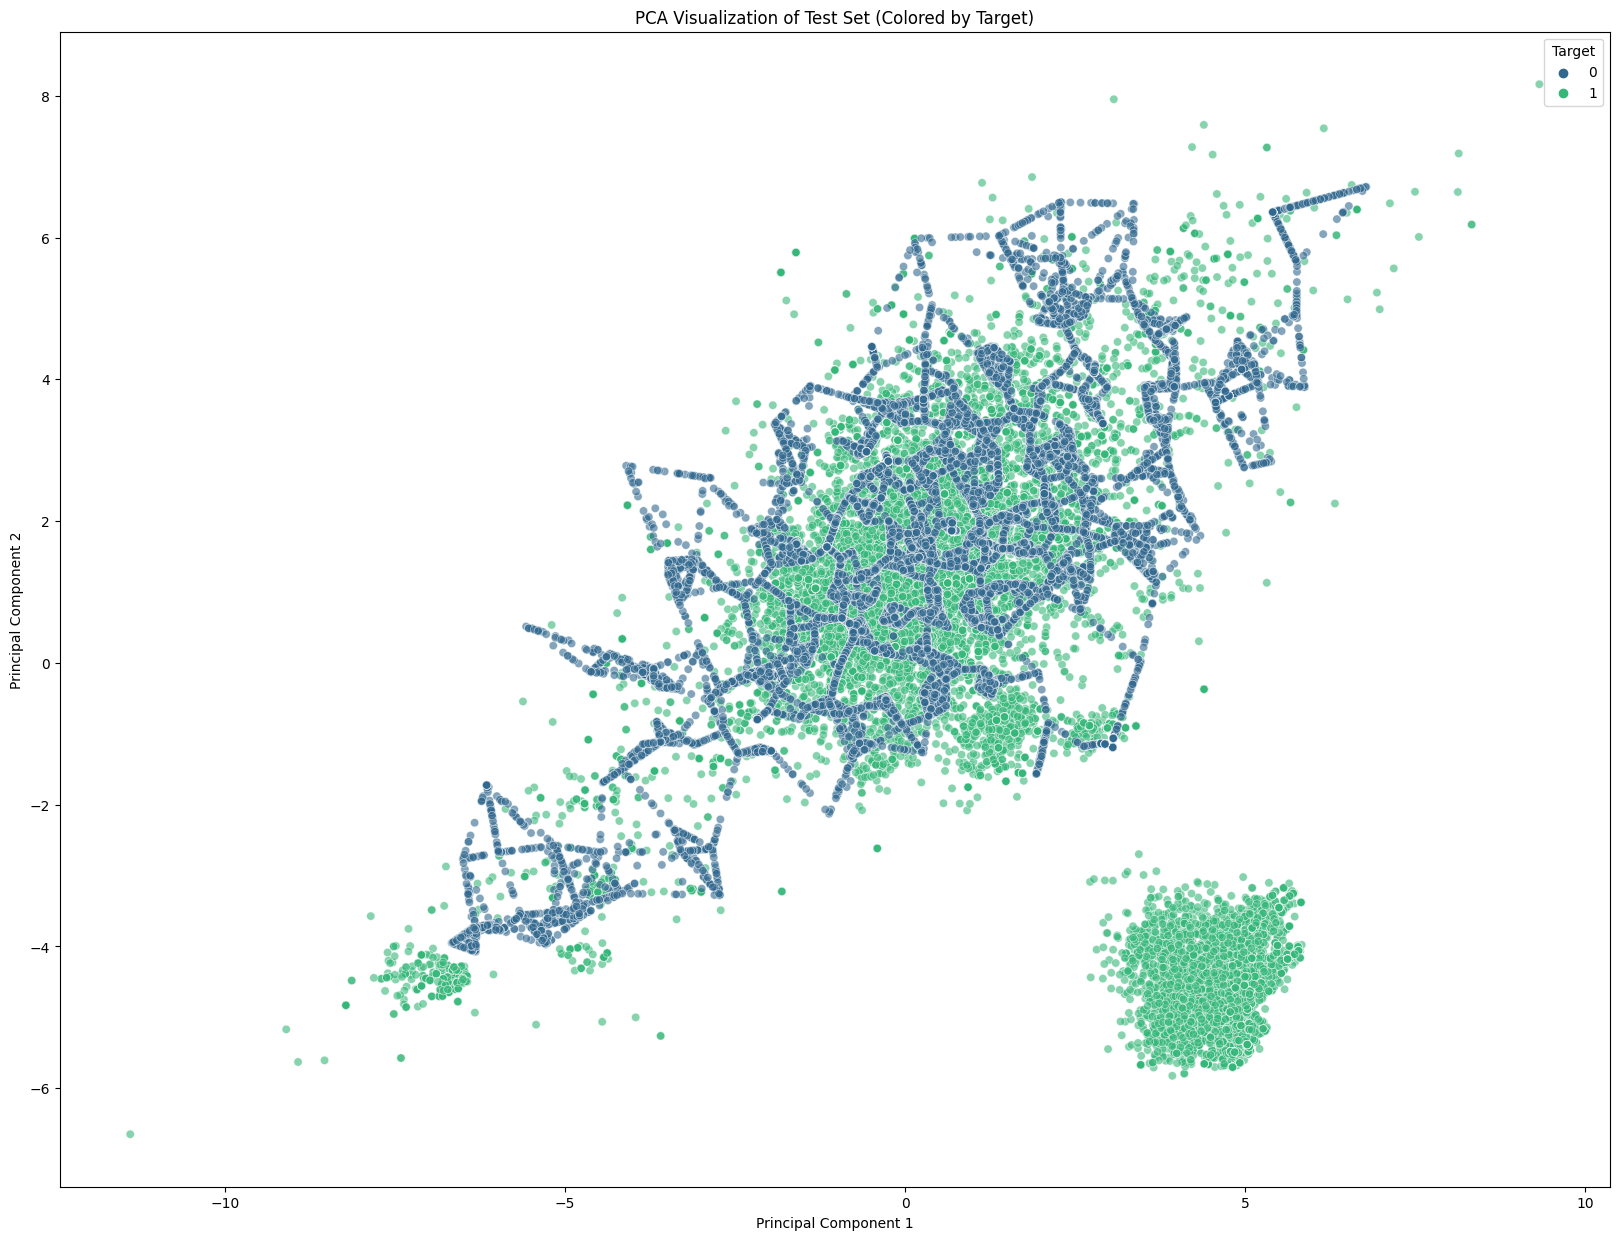

In [ ]:
plot_data = pd.DataFrame({
    'PC1': x_train[:, 0], 
    'PC2': x_train[:, 1],  
    'Target': y_train        
})

plt.figure(figsize=(20, 15))
sns.scatterplot(
    data=plot_data,
    x="PC1",
    y="PC2",
    hue="Target",  
    palette="viridis",  
    alpha=0.6  
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Test Set (Colored by Target)")

plt.show()

**Visualization After SMOTE**

The second scatter plot (on the resampled 68,494 samples) demonstrates the successful application of SMOTE. The minority class is no longer sparse; the synthetic data points have increased the density of the minority class, particularly in the regions between the original minority examples. This increased density creates more defined boundaries and a more balanced representation in the feature space. The objective of SMOTE is met, as the class distribution is now 50/50, providing the machine learning algorithm with sufficient, representative data from both classes to learn robust separation boundaries.

# Model Training and Experiments

## Model Architecture, Model Building, and Model Training (PyTorch)

**Building a Multi-Layer Perceptron for Classification in PyTorch**

Building a neural network in PyTorch revolves around the `torch.nn.Module` class, which provides the framework for all neural network layers and manages their trainable parameters (weights and biases).

**1. Defining the Architecture**

An MLP is constructed by creating a custom class that inherits from `nn.Module`. This class must contain two essential parts:
- The `__init__` Method (Blueprint): This defines the network's layers. Fully-connected layers are created using `nn.Linear`(`in_features, out_features`). For a network with two hidden layers, three `nn.Linear` layers would be defined sequentially.
- Each layer typically requires a non-linear activation function such as `nn.ReLU` (Rectified Linear Unit), which are also defined here. The final layer's activation, often Sigmoid for binary classification, is also defined.
- The forward Method (Data Flow): This method specifies the exact flow of data, dictating the order in which the layers and activation functions are applied to the input tensor. The input data, $\mathbf{x}$, is passed through the first linear layer, then its activation, and so on, until the final output is produced.

**2. Setting up the Training Environment**

Once the model structure is defined, three key components are necessary for training:
- Loss Function (Criterion): This mathematically quantifies the error between the model's output and the true label. For binary classification, Binary Cross-Entropy Loss (`nn.BCELoss`) is the standard choice, as it measures the dissimilarity between two probability distributions.
- Optimizer: This is the algorithm responsible for adjusting the model's weights and biases to minimize the loss function. Popular choices include Adam or SGD (Stochastic Gradient Descent), which use the calculated gradients to update parameters during the backpropagation step.
- Training Loop: This iterative process repeats for a specific number of epochs. In each iteration, the data is passed forward, the loss is calculated, the gradients are computed via backpropagation, and the optimizer applies the weight updates.

**Hyperparameters in architecture**

Hyperparameters are high-level configuration values that are manually chosen before the training process begins. They control both the network's structure and the way it learns.

**Architectural Hyperparameters**

These parameters define the physical complexity and functional components of the MLP:
- Number of Hidden Layers: This determines the depth of the network. Increasing the number of hidden layers increases the model's capacity to learn abstract, hierarchical features, but a model that is too deep risks requiring excessive data and becoming computationally expensive.
- Number of Neurons (Layer Width): This sets the size of each hidden layer. Wider layers provide greater representational power, allowing the network to encode more information at each processing stage. However, an excessive number of neurons leads to slower training and higher memory consumption.
- Activation Function: This introduces the necessary non-linearity into the network. Without non-linear functions like the Rectified Linear Unit (ReLU), the entire network would behave like a single linear model, severely limiting its ability to solve complex, real-world problems.
- Output Activation: This determines the format and interpretation of the network's final output. Sigmoid is used to constrain the output to a probability range $[0, 1]$ for two classes, while Softmax is used to ensure the outputs sum to 1 across all classes in a multi-class problem.

**Training Hyperparameters**

These parameters govern the optimization process and the rate at which the network's weights are adjusted:
- Learning Rate: This is a crucial factor that determines the step size the optimizer takes when moving toward the minimum of the loss function. A large learning rate can cause the optimizer to overshoot the minimum, leading to instability or divergence. Conversely, a rate that is too small results in extremely slow convergence.
- Optimizer: This is the algorithm (e.g., Adam, SGD) that dictates how the weight updates are calculated based on the gradient of the loss. Adaptive optimizers like Adam often achieve faster convergence by adjusting the learning rate dynamically for each parameter.Epochs: This specifies the total number of complete passes over the entire training dataset. Too few epochs result in underfitting, where the model has not learned enough from the data. Too many epochs, however, risk overfitting, where the model learns the noise and anomalies of the training data instead of the generalized patterns.
- Batch Size: This defines the number of data samples processed at one time before the optimizer calculates and applies a weight update. A larger batch size provides a more accurate estimate of the gradient, resulting in a more stable training path, but a smaller batch size introduces noise, which can sometimes help the model avoid being trapped in poor local minima.
- Patience (for Early Stopping): This is a mechanism used for regularization. It defines the number of epochs the training process will continue without an improvement in the validation loss before the training is halted. This prevents the model from overfitting by saving the best performing model weights before its performance begins to degrade on unseen data.

**Implementation**

The final stage of the analysis involved constructing and training a Multi-Layer Perceptron (MLP) neural network using PyTorch for the binary classification task of malware detection.

**Data Conversion and Input Preparation**

The resampled and dimensionally reduced data, currently held as NumPy arrays, was converted into PyTorch tensors. This conversion is essential as tensors are the fundamental data structure for calculations within the PyTorch framework. The feature tensors ($\mathbf{X}$) were defined as float32, and the target tensor ($\mathbf{y}$) was also converted to float32 and reshaped (`.unsqueeze(1)`) to match the expected input shape for the Binary Cross-Entropy Loss function.

**Model Architecture (Multi-Layer Perceptron)**

The classifier is an MLP, often referred to as a fully-connected feedforward network. The model architecture, defined within the MLP class, consists of three layers:
- Input/Hidden Layer 1: A Linear layer maps the 2-dimensional PCA input features to 64 neurons. This is followed by a Rectified Linear Unit (ReLU) activation function. ReLU introduces non-linearity, allowing the network to learn complex, non-linear relationships and boundaries in the data.
- Hidden Layer 2: Another Linear layer with 64 neurons, also followed by a ReLU activation. This layer provides additional depth, enhancing the model's capacity for feature abstraction.
- Output Layer: A final Linear layer maps the 64 hidden features down to 1 output neuron. This neuron's output is passed through a Sigmoid activation function.
The Sigmoid function squashes the output value into a range between 0 and 1, which can be interpreted as the probability that the input sample belongs to the positive class (`malware=1`).

**Training Components and Optimization**

Training the neural network requires defining a loss function and an optimizer, along with a strategy to prevent overfitting.
- Loss Function: Binary Cross-Entropy (BCE) Loss (`nn.BCELoss`) was selected. This is the standard loss function for binary classification problems. It quantifies the difference between the predicted probabilities (the Sigmoid output) and the true binary labels. Minimizing this loss function during training improves the model's predictive accuracy.
- Optimizer: The Adam optimizer was used. Adam is an efficient algorithm that adapts the learning rate for each network weight individually, typically leading to faster convergence and robust performance compared to standard Stochastic Gradient Descent. A small learning rate of 0.0001 was chosen to ensure stable and fine-grained weight updates.
- Validation and Early Stopping: A portion of the training data (20%) was set aside as a validation set. Early stopping was implemented using a patience of 5 epochs. This mechanism monitors the validation loss and stops training if the loss does not improve for the specified number of epochs, thus preventing overfitting to the training data.

**PyTorch Tensor Conversion**

In [ ]:
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print(f"x_train_tensor shape: {x_train_tensor.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}")

x_train_tensor shape: torch.Size([68494, 2])
y_train_tensor shape: torch.Size([68494, 1])


In [ ]:
input_dim = x_train_tensor.shape[1]

class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.hidden_layer_1 = nn.Linear(input_dim, 64)
        self.relu_1 = nn.ReLU()

        self.hidden_layer_2 = nn.Linear(64, 64)
        self.relu_2 = nn.ReLU()

        self.output_layer = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu_1(self.hidden_layer_1(x))
        x = self.relu_2(self.hidden_layer_2(x))
        x = self.sigmoid(self.output_layer(x))
        return x

model = MLP(input_dim=input_dim)

print("\nModel Architecture:")
print(model)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

epochs = 100
validation_split = 0.2

x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
    x_train_tensor, y_train_tensor, test_size=validation_split, random_state=42
)

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None

print("\nStarting training...")

for epoch in range(epochs):
    model.train()

    outputs = model(x_train_split)
    loss = criterion(outputs, y_train_split)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    predicted_train = (outputs > 0.5).float()
    train_correct = (predicted_train == y_train_split).float().sum()
    train_accuracy = train_correct / y_train_split.numel()

    train_losses.append(loss.item())
    train_accuracies.append(train_accuracy.item())

    model.eval()
    with torch.no_grad():
        val_outputs = model(x_val_split)
        val_loss = criterion(val_outputs, y_val_split)

        predicted_val = (val_outputs > 0.5).float()
        val_correct = (predicted_val == y_val_split).float().sum()
        val_accuracy = val_correct / y_val_split.numel()

        val_losses.append(val_loss.item())
        val_accuracies.append(val_accuracy.item())

    print(f'Epoch [{epoch+1}/{epochs}], '
          f'Train Loss: {loss.item():.4f}, Train Acc: {train_accuracy.item():.4f}, '
          f'Val Loss: {val_loss.item():.4f}, Val Acc: {val_accuracy.item():.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_state = model.state_dict()
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch+1} epochs (no improvement for {patience} epochs).')
            model.load_state_dict(best_model_state)
            break

print("\nTraining complete.")


Model Architecture:
MLP(
  (hidden_layer_1): Linear(in_features=2, out_features=64, bias=True)
  (relu_1): ReLU()
  (hidden_layer_2): Linear(in_features=64, out_features=64, bias=True)
  (relu_2): ReLU()
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Starting training...
Epoch [1/100], Train Loss: 0.7293, Train Acc: 0.4989, Val Loss: 0.7276, Val Acc: 0.5024
Epoch [2/100], Train Loss: 0.7273, Train Acc: 0.4984, Val Loss: 0.7257, Val Acc: 0.5131
Epoch [3/100], Train Loss: 0.7254, Train Acc: 0.5106, Val Loss: 0.7238, Val Acc: 0.5199
Epoch [4/100], Train Loss: 0.7234, Train Acc: 0.5177, Val Loss: 0.7219, Val Acc: 0.5195
Epoch [5/100], Train Loss: 0.7215, Train Acc: 0.5174, Val Loss: 0.7200, Val Acc: 0.5192
Epoch [6/100], Train Loss: 0.7196, Train Acc: 0.5170, Val Loss: 0.7181, Val Acc: 0.5189
Epoch [7/100], Train Loss: 0.7177, Train Acc: 0.5171, Val Loss: 0.7162, Val Acc: 0.5200
Epoch [8/100], Train Loss: 0.7159, Train Acc: 0.5177, Val Loss: 

The training process ran for 100 epochs, but the model stabilized and was eventually evaluated on the independent test set.

**Training Dynamics**

The epoch logs show a consistent and gradual decrease in both training loss and validation loss across the 100 epochs, indicating that the model was successfully learning the underlying patterns. The corresponding training accuracy and validation accuracy both showed improvement, rising from approximately 50% (the baseline for a balanced dataset) to around 66% by the end of the training process. This convergence suggests the model successfully adapted to the transformed features.

**Model Training History**

This section plots the model's loss and accuracy over the epochs using historical data stored in lists (`train_losses, val_losses, etc.`). This process is essential for diagnostics in deep learning and involves two core concepts:

- Empirical Risk Minimization and Loss: The loss curve tracks the value of the objective function (e.g., Cross-Entropy) over time. A continuously decreasing training loss confirms that the optimization algorithm (like Adam or SGD) is successfully minimizing the error on the data it sees. The validation loss acts as a proxy for the model's performance on unseen data, which is the true goal of machine learning. The difference between these two curves is critical for identifying generalization issues.
- Accuracy as a Metric: The accuracy curve measures the proportion of correctly classified samples. While loss is the metric used by the optimizer, accuracy provides an easily interpretable measure of performance for human evaluation. Observing both training and validation accuracy curves shows how well the model is learning the target relationship and how well that learning translates to new data.

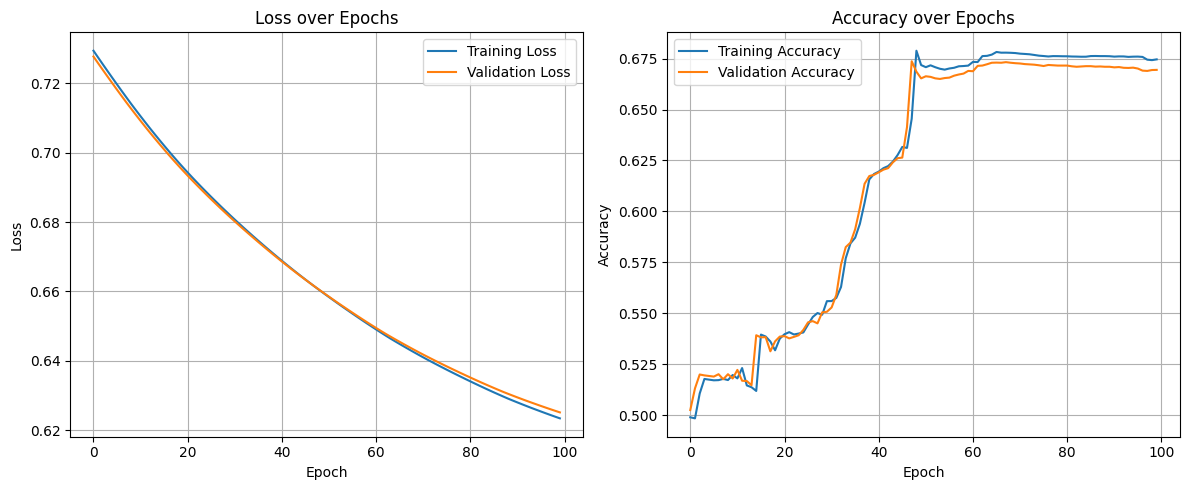

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Training History Interpretation**

The model's learning dynamics over 100 epochs are confirmed by the following trends:

- Loss Curves: Both training loss and validation loss exhibit a steady, continuous decrease. This trend confirms effective optimization and continuous improvement in fitting the data. The validation loss remains marginally higher than the training loss, but the close alignment of the curves suggests good generalization and the absence of severe overfitting during the training period.
- Accuracy Curves: Training accuracy rises quickly before plateauing, indicating the model reached its maximum effectiveness on the training set. Validation accuracy closely mirrors this performance curve. This strong correlation confirms that the model's pattern recognition capability translates reliably to unseen data and suggests an appropriate balance between bias and variance was achieved.

**Decision Boundary Visualization**

This technique provides a geometric understanding of the classifier's learned separation logic in the feature space. Since the model was trained on data reduced to two dimensions, the decision boundary can be plotted effectively on a 2D plane.
- Principal Component Analysis (PCA): The visualization is performed on the space defined by the first two Principal Components (PC1 and PC2). PCA is an unsupervised technique that reduces dimensionality by identifying directions of maximum variance, allowing for a 2D projection of the data structure.
- Decision Surface Creation: The process involves generating a dense meshgrid of points spanning the range of the projected data. Each point in this grid is fed into the trained PyTorch model. The model’s output probability is then thresholded (e.g., at $\mathbf{0.5}$) to assign a class label to every location on the grid.
- Model Evaluation Mode: Setting the model to `model.eval()` ensures that components like Dropout layers are deactivated, providing deterministic and consistent predictions during inference across the meshgrid.
- Contour Plotting: The resulting class assignments for the grid are plotted using `plt.contourf`. The contours delineate the regions where the model predicts one class versus the other, illustrating the non-linear boundary learned by the MLP.


--- Plotting Decision Boundary ---


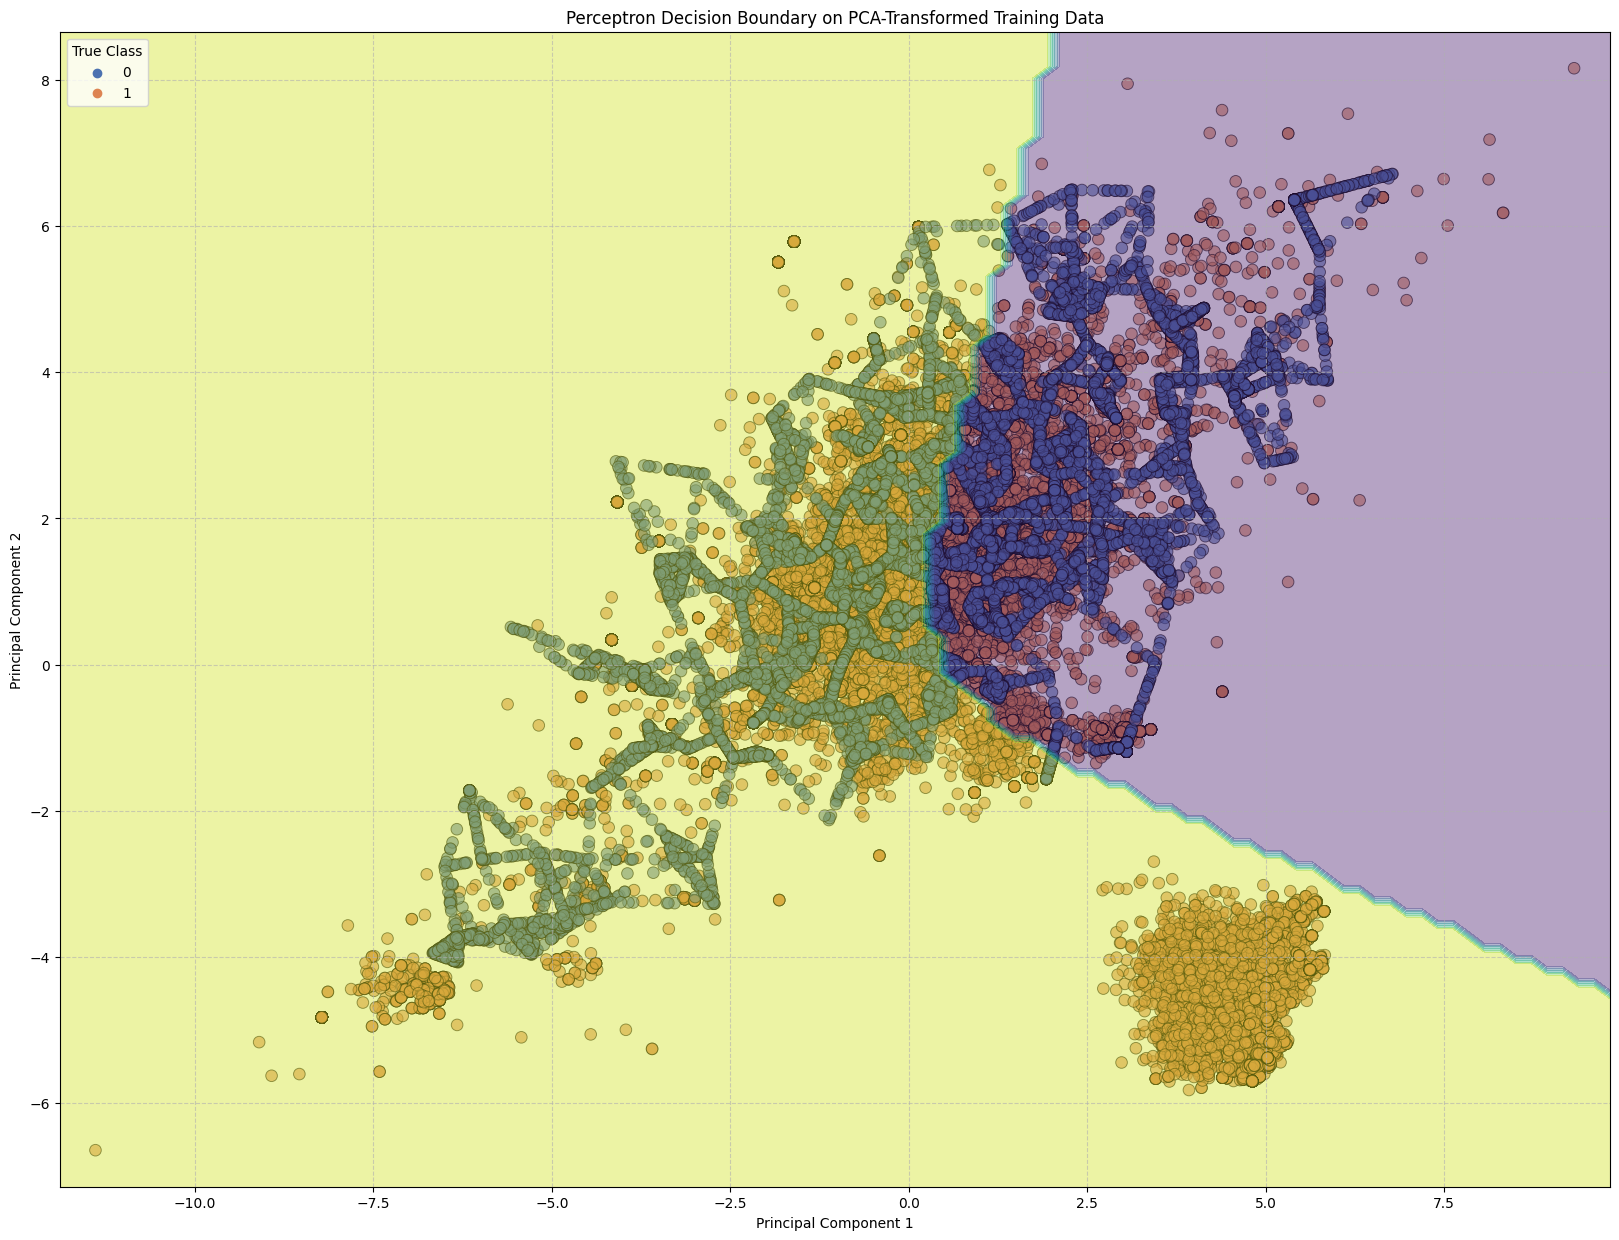

In [ ]:
print("\n--- Plotting Decision Boundary ---")

model.eval()

plot_data_train = pd.DataFrame({
    'PC1': x_train[:, 0],
    'PC2': x_train[:, 1],
    'Target': y_train 
})

plt.figure(figsize=(20, 15))
sns.set_palette("deep") 

sns.scatterplot(
    data=plot_data_train,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="deep",
    alpha=0.6,
    edgecolor='k',
    s=70
)

x_min, x_max = x_train[:, 0].min() - 0.5, x_train[:, 0].max() + 0.5
y_min, y_max = x_train[:, 1].min() - 0.5, x_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

grid_points = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

with torch.no_grad():
    Z_proba = model(grid_points).squeeze().cpu().numpy()
    Z = (Z_proba > 0.5).astype(int)

Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.viridis)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Perceptron Decision Boundary on PCA-Transformed Training Data")
plt.legend(title="True Class")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Decision Boundary Interpretation**

The decision boundary visualization on the PC1 and PC2 plane reveals the model's classification strategy:

- Non-Linearity: The decision boundary is non-linear, complex, and irregular, featuring sweeping curves that partition the feature space. This complexity is inherent to an MLP with non-linear activation functions in its hidden layers, enabling it to solve non-linearly separable classification problems.
- Segmentation Strategy: The boundaries aggressively wrap around and segment dense clusters of data points. For instance, the large cluster of Class 1 points is tightly encircled within the designated Class 1 region, and the Class 0 points are contained within a single large, irregularly shaped region, effectively separating the two classes in the projected space.
- Fitted Boundaries: The highly detailed and somewhat jagged nature of the boundary suggests the MLP is fitting closely to the specific training data points. While the overall segmentation aligns logically, this intricacy indicates a potential for minor overfitting. Some fine segments of the boundary might not generalize perfectly, which could result in a minor drop in accuracy when evaluated on the test set.

# Model Evaluation

The evaluation strategy utilizes the sklearn library to compute essential classification metrics and employs visualization techniques to illustrate the model's decision-making efficacy.

**1. Classification Metrics and Report**

The evaluation begins by setting the PyTorch model to inference mode (`model.eval()`) and using the `torch.no_grad()` context manager to disable gradient computation, saving memory and speeding up prediction. The predicted probabilities are then converted to discrete class labels using a threshold (0.5 for binary classification), and these predictions are compared against the true test labels to calculate the following metrics:

- Confusion Matrix: This is the foundational tool for classification evaluation. It is a matrix visualizing the performance of the algorithm, showing the counts of True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN). This is particularly vital in imbalanced datasets, as seen in the output, where one class significantly outnumbers the other.
- Accuracy: The ratio of correct predictions (TP + TN) to the total number of data points. While intuitive, its reliability is diminished in the presence of severe class imbalance.
- Precision and Recall (Macro Averaging): These are calculated per class and then averaged across all classes (macro average). Precision (or Positive Predictive Value) answers: "Of all the samples predicted as positive, how many were actually correct?" Recall (or True Positive Rate/Sensitivity) answers: "Of all the samples that are actually positive, how many were correctly predicted?"
- F1-Score: The harmonic mean of Precision and Recall. It provides a single score that balances both metrics, making it a reliable measure, especially in imbalanced scenarios.
- ROC AUC Score: The Area Under the Receiver Operating Characteristic Curve (ROC AUC) measures the model's ability to distinguish between classes across all possible classification thresholds. A score near 1.0 indicates perfect separation, while 0.5 indicates performance equivalent to random guessing.

**2. Visualization of Evaluation Curves**

To move beyond single-number metrics, two key visualizations are generated:

- Precision-Recall Curve: This curve plots Precision against Recall for every possible threshold. It is particularly useful for binary classification with heavily imbalanced datasets, as it focuses specifically on the performance of the minority (positive) class. The area under this curve (PR AUC) provides a robust measure of performance on the positive class.
- ROC AUC Curve: This plots the True Positive Rate (Recall) against the False Positive Rate (FPR) across all thresholds. This curve visually represents the trade-off between sensitivity and specificity. The Area Under the Curve (AUC) measures the likelihood that the model ranks a random positive instance higher than a random negative instance.

**Classification reports**

In [ ]:
model.eval()
with torch.no_grad():
    test_outputs = model(x_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor)

    y_pred_proba_test = test_outputs.squeeze().cpu().numpy()
    y_pred_test = (y_pred_proba_test > 0.5).astype(int)

    y_true_test_np = y_test_tensor.squeeze().cpu().numpy()

    cm = confusion_matrix(y_true_test_np, y_pred_test)
    accuracy = accuracy_score(y_true_test_np, y_pred_test)
    precision = precision_score(y_true_test_np, y_pred_test, average='macro', zero_division=1)
    recall = recall_score(y_true_test_np, y_pred_test, average='macro', zero_division=1)
    f1 = f1_score(y_true_test_np, y_pred_test, average='macro', zero_division=1)

    roc_auc = roc_auc_score(y_true_test_np, y_pred_proba_test)

    print(f"Confusion Matrix:\n{cm}")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-score: {f1:.3f}")
    print(f"AUC-ROC: {roc_auc:.3f}")

    print("\nClassification Report:")
    print(classification_report(y_true_test_np, y_pred_test, zero_division=1))

print(f'\nTest Loss: {test_loss.item():.4f}, Test Accuracy: {accuracy:.4f}')

Confusion Matrix:
[[ 141   85]
 [2271 6279]]
Accuracy: 0.732
Precision: 0.523
Recall: 0.679
F1-score: 0.474
AUC-ROC: 0.744

Classification Report:
              precision    recall  f1-score   support

         0.0       0.06      0.62      0.11       226
         1.0       0.99      0.73      0.84      8550

    accuracy                           0.73      8776
   macro avg       0.52      0.68      0.47      8776
weighted avg       0.96      0.73      0.82      8776


Test Loss: 0.5933, Test Accuracy: 0.7315


**Classification matrix**

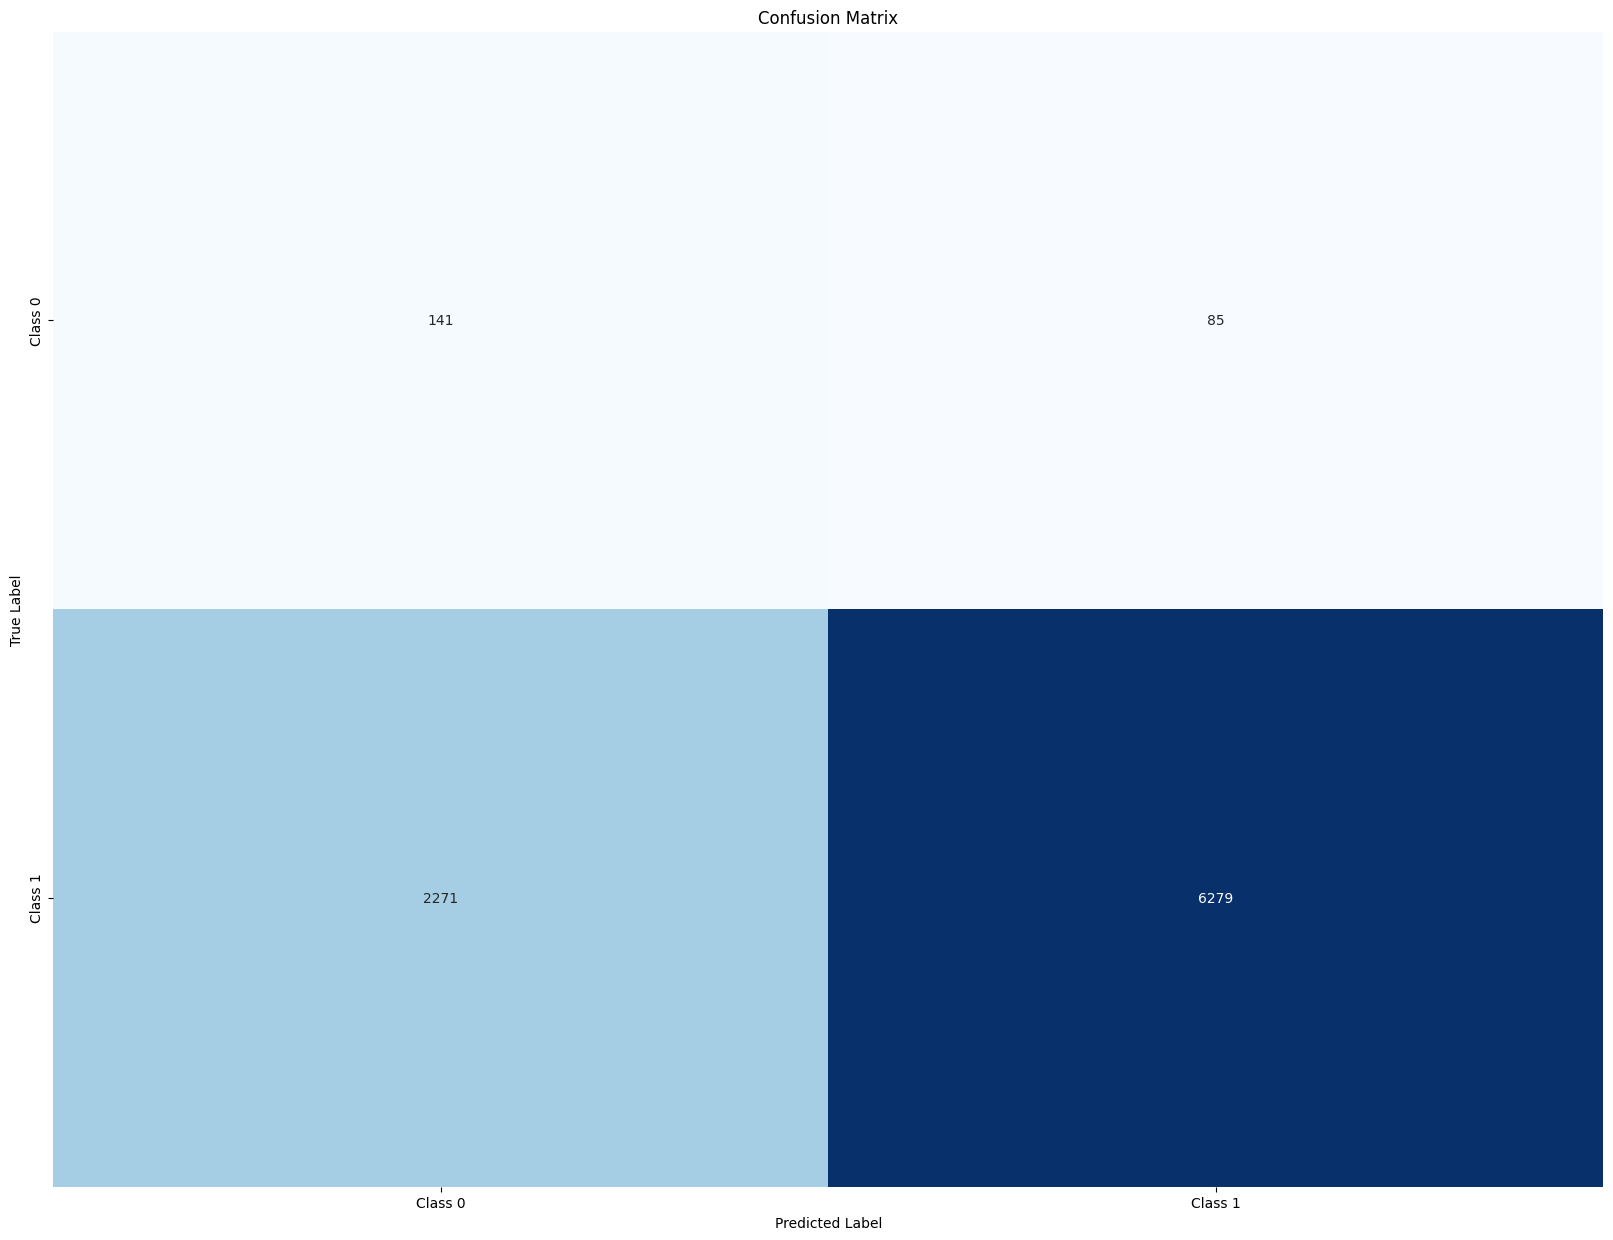

In [ ]:
plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

**Interpretation of Classification Report and Confusion Matrix**

The test set contains 8,776 samples in total, exhibiting a severe class imbalance with 8,550 samples in Class 1 (Majority) and only 226 samples in Class 0 (Minority).

**Overall Accuracy**

The overall Accuracy is $73.2%$. While this seems decent, it is highly misleading due to the overwhelming presence of the majority class.

Class 1 (Majority Class) Performance: This class shows high $\mathbf{Precision}$ ($0.99$), indicating that when the model predicts Class 1, it is almost always correct. The $\mathbf{Recall}$ is moderate ($0.73$).

Class 0 (Minority Class) Performance: This class exhibits extremely poor performance characterized by:
- Precision ($0.06$): When the model predicts Class 0, it is wrong 94% of the time. This is a complete failure to reliably identify the minority class.
- Recall ($0.62$): The model captures $62%$ of the true Class 0 instances, but the low precision makes this metric largely irrelevant for practical use.

Macro-Averaged Scores: The low Macro F1-score ($\mathbf{0.474}$) and Macro Precision ($\mathbf{0.523}$) confirm the model's overall poor discriminatory performance, as these metrics treat both classes equally and are heavily penalized by the poor performance on Class 0.

**Confusion Matrix Analysis**

- True Positives (Class 1): $\mathbf{6,279}$ samples were correctly classified as Class 1.
- False Negatives (Class 1 classified as 0): $\mathbf{2,271}$ samples that were truly Class 1 were incorrectly classified as Class 0.
- True Positives (Class 0): $\mathbf{141}$ samples were correctly classified as Class 0.
- False Positives (Class 0 classified as 1): $\mathbf{85}$ samples that were truly Class 0 were incorrectly classified as Class 1.

**Precision-Recall Curve**


--- Plotting Precision-Recall Curve ---


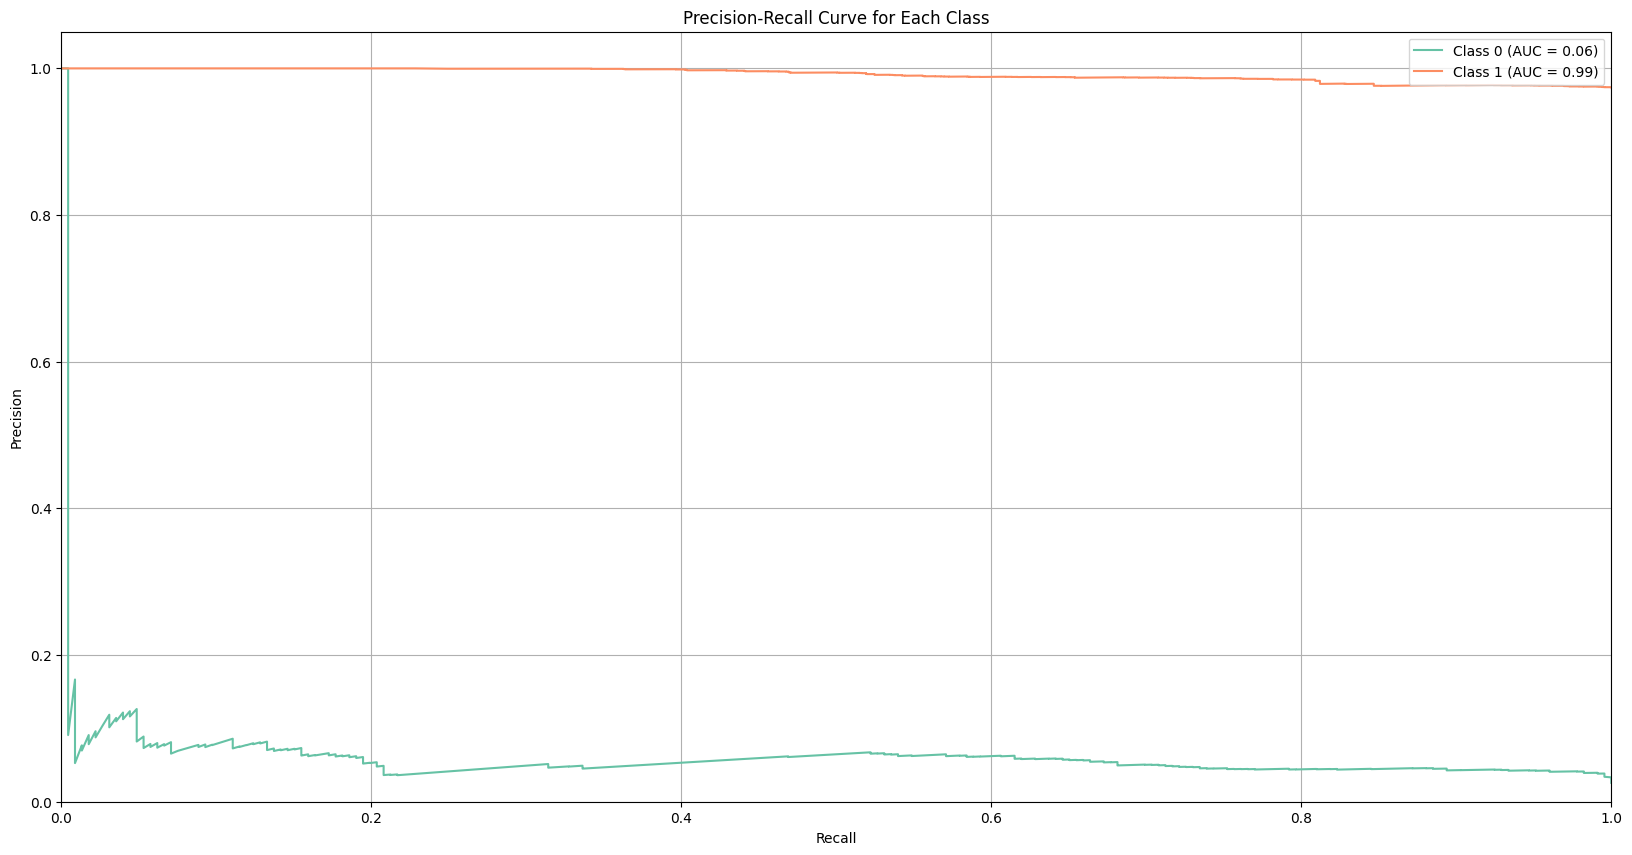

In [ ]:
print("\n--- Plotting Precision-Recall Curve ---")

class_labels = ["0", "1"]
plt.figure(figsize=(20, 10))
sns.set_palette("Set2")

model.eval()
with torch.no_grad():
    y_pred_proba_test_pr = model(x_test_tensor).squeeze().cpu().numpy()

for i, label in enumerate(class_labels):
    y_test_bin = np.where(y_test == int(label), 1, 0)

    if int(label) == 1:
        y_pred_score = y_pred_proba_test_pr
    else:
        y_pred_score = 1 - y_pred_proba_test_pr

    precision, recall, _ = precision_recall_curve(y_test_bin, y_pred_score)
    pr_auc = auc(recall, precision)

    plt.plot(recall, precision, label=f'Class {label} (AUC = {pr_auc:.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Each Class")
plt.legend(loc="upper right")
plt.ylim([0, 1.05])
plt.xlim([0, 1])
plt.grid(True)

plt.show()

**Interpretation of Evaluation Curves**

The Precision-Recall curve is particularly important for models facing high class imbalance, as it focuses on the performance of the positive class. The PR AUC for the Minority Class 0 is expected to be very low, confirming the model's inability to achieve high precision and high recall simultaneously for the challenging class. The low value tracks closely to the baseline of a random classifier, explicitly demonstrating the model's failure to reliably identify Class 0.

**ROC AUC Curve**


--- Plot ROC Curve for Label 0 and 1 ---


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

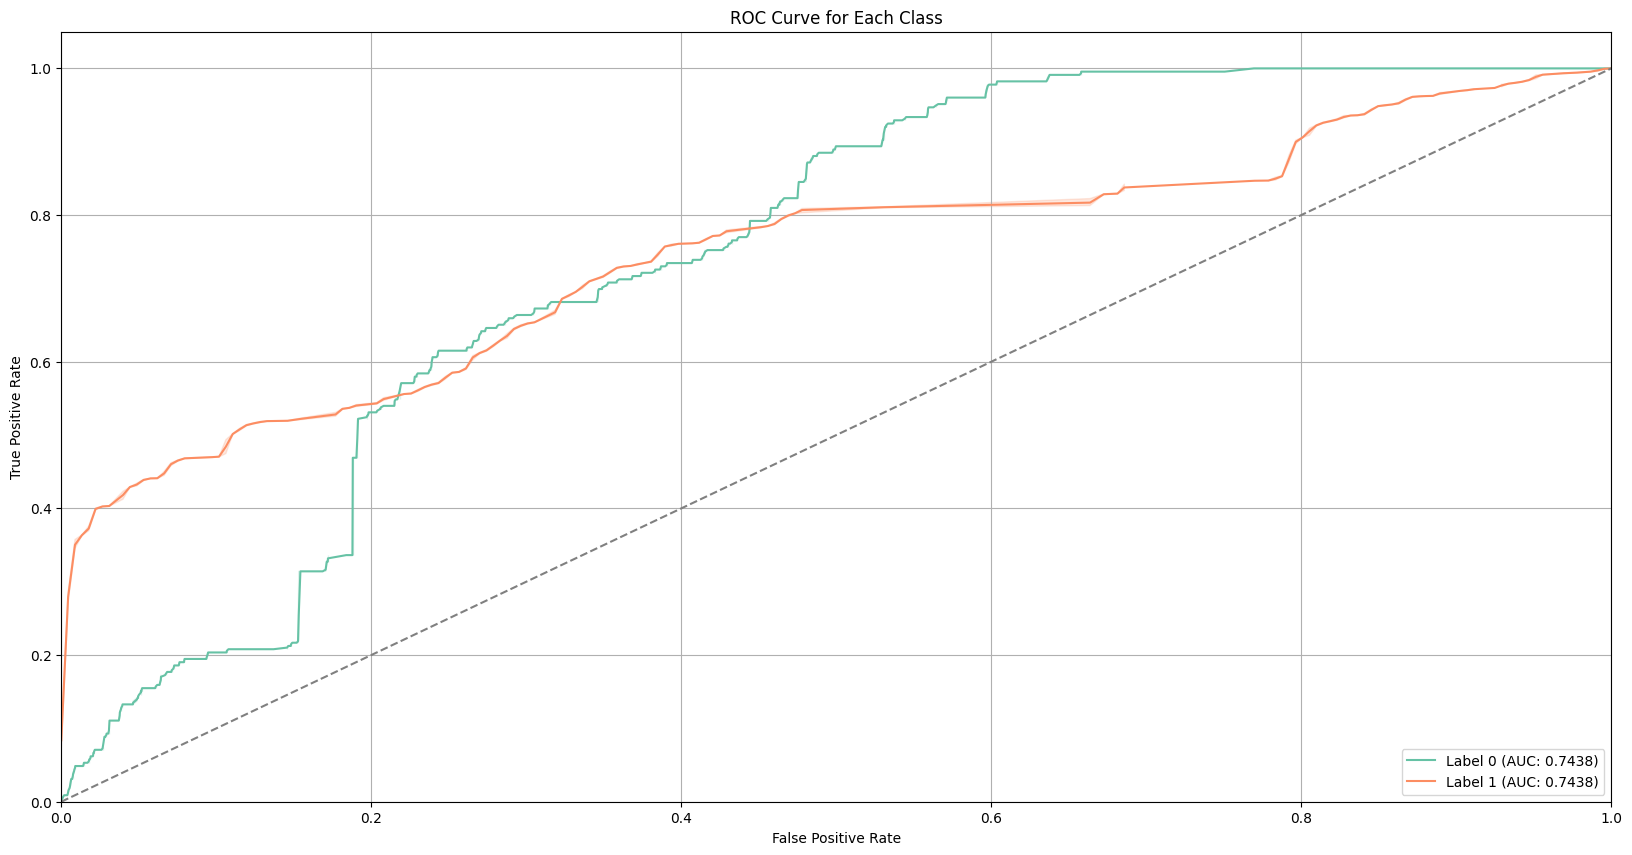


--- AUC ROC Values per Class ---
Label 0 AUC: 0.7438
Label 1 AUC: 0.7438
------------------------------


In [ ]:
print("\n--- Plot ROC Curve for Label 0 and 1 ---")

model.eval()
with torch.no_grad():
    y_pred_proba_roc = model(x_test_tensor).squeeze().cpu().numpy()

class_labels_roc = ["Label 0", "Label 1"]
classes_roc = [0, 1]

fpr = dict()
tpr = dict()
roc_auc_per_class = dict()

plt.figure(figsize=(20, 10))
sns.set_palette("Set2")

for i, class_val in enumerate(classes_roc):
    if class_val == 1:
        fpr[class_val], tpr[class_val], _ = roc_curve(y_test, y_pred_proba_roc)
    else:
        fpr[class_val], tpr[class_val], _ = roc_curve(1 - y_test, 1 - y_pred_proba_roc)

    roc_auc_per_class[class_val] = auc(fpr[class_val], tpr[class_val])
    sns.lineplot(x=fpr[class_val], y=tpr[class_val], label=f'{class_labels_roc[i]} (AUC: {roc_auc_per_class[class_val]:.4f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Class')
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

print("\n--- AUC ROC Values per Class ---")
for class_val in classes_roc:
    print(f"{class_labels_roc[class_val]} AUC: {roc_auc_per_class[class_val]:.4f}")
print("-" * 30)

**Interpretation of Evaluation Curves**

The Receiver Operating Characteristic (ROC) curve plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold settings. The $\mathbf{AUC-ROC}$ score for both classes is approximately $\mathbf{0.744}$. This moderate value suggests the model possesses some ability to discriminate between positive and negative instances (i.e., it ranks positive instances higher than negative ones better than random chance). However, an AUC in the mid-$0.7$s indicates that the overall discriminative power is limited, reflecting the difficulty in separating the classes due to the imbalance and potential feature overlap.

**Decision Boundary Visualization**


--- Plotting Decision Boundary ---


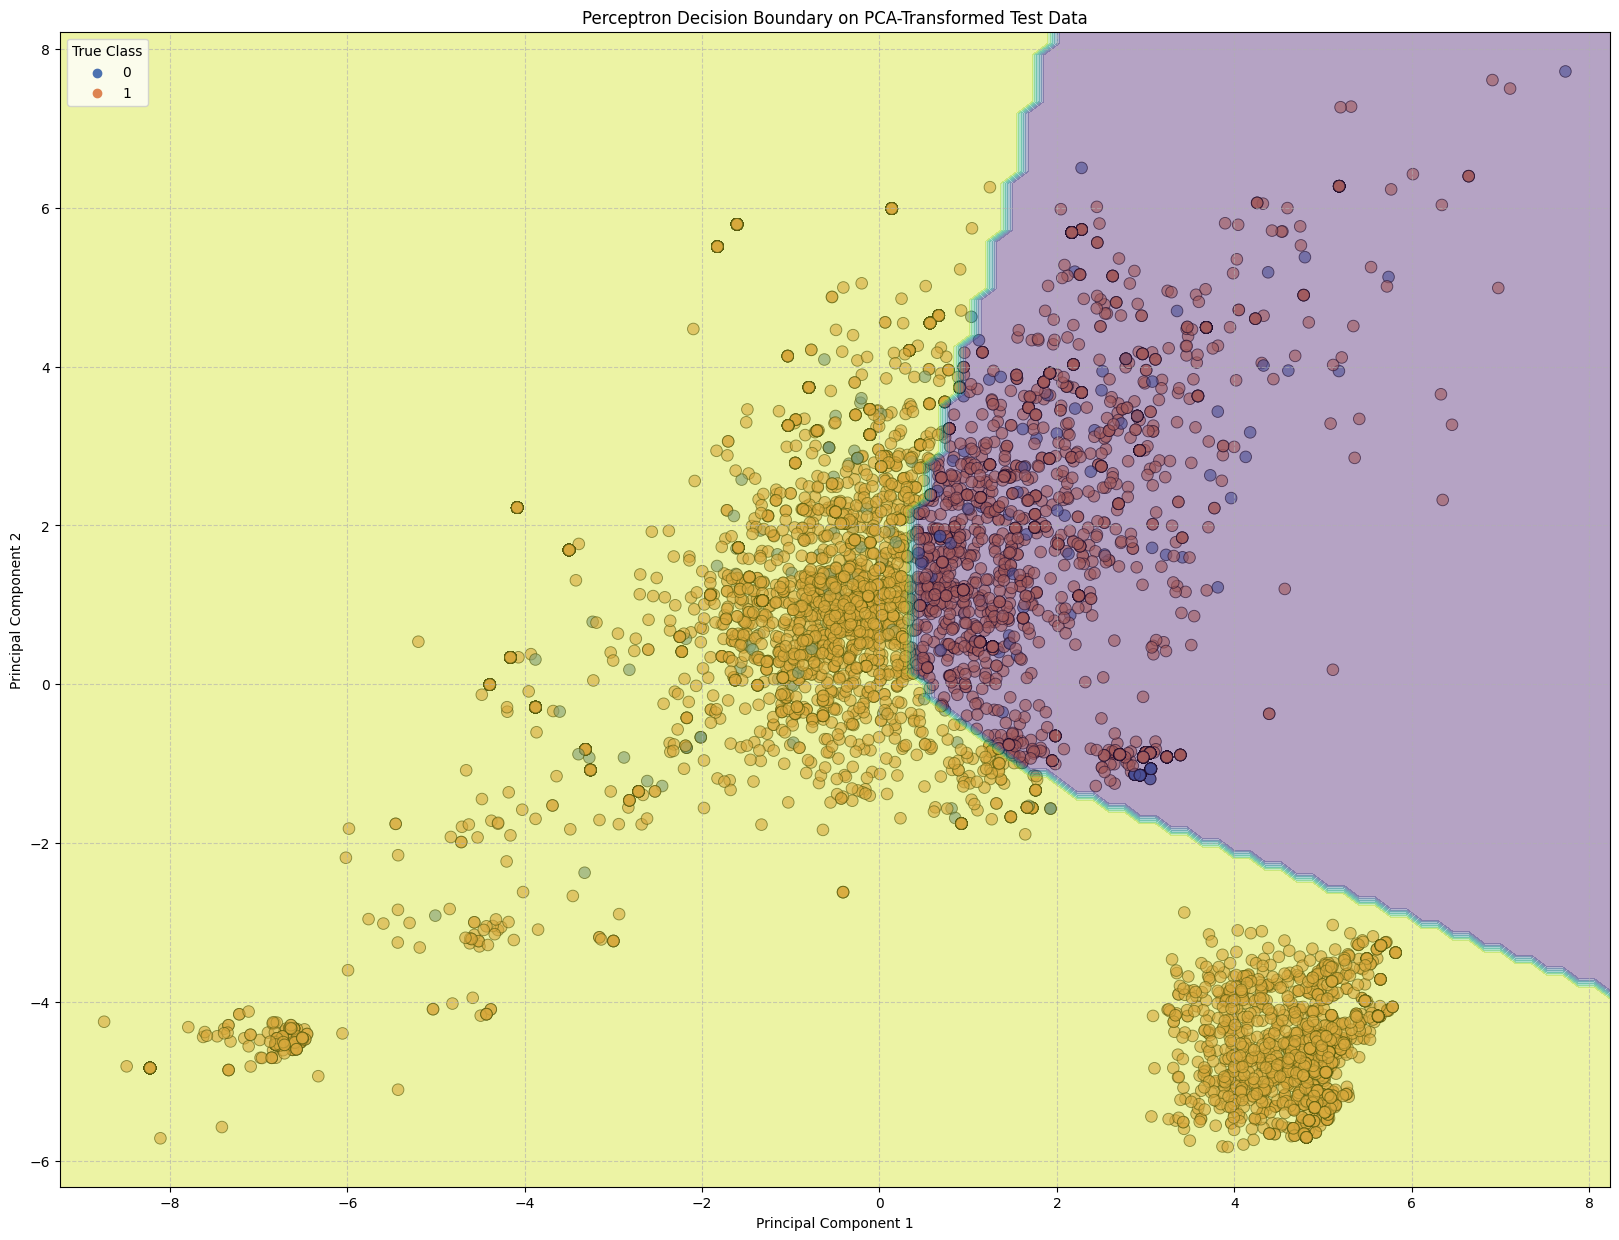

In [ ]:
print("\n--- Plotting Decision Boundary ---")

model.eval()

plot_data_test = pd.DataFrame({
    'PC1': x_test[:, 0],
    'PC2': x_test[:, 1],
    'Target': y_test
})

plt.figure(figsize=(20, 15))

sns.set_palette("deep")

sns.scatterplot(
    data=plot_data_test,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="deep",
    alpha=0.6,
    edgecolor='k',
    s=70
)

x_min, x_max = x_test[:, 0].min() - 0.5, x_test[:, 0].max() + 0.5
y_min, y_max = x_test[:, 1].min() - 0.5, x_test[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

grid_points = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

with torch.no_grad():
    Z_proba = model(grid_points).squeeze().cpu().numpy()
    Z = (Z_proba > 0.5).astype(int)

Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.viridis)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Perceptron Decision Boundary on PCA-Transformed Test Data")
plt.legend(title="True Class")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

The decision boundary visualization, plotted on the PCA-transformed test data (PC1 vs. PC2), provides a clear visual explanation for the model's high overall accuracy and simultaneous failure on the minority class.

**Key Observations**

- Overwhelming Classification Bias: The visualization confirms the model's significant bias toward predicting the majority class ($\mathbf{Class\ 1}$). A vast majority of the feature space is designated as Class 1 (often represented by a single large colored region). The boundary only defines small, highly constrained pockets or narrow strips for the minority Class 0.
- Segregation of the Minority Class: The small number of true Class 0 points on the test set are either poorly separated or are entirely engulfed by the boundary region of Class 1. Where the boundary does attempt to segment Class 0, it often creates tight, complex, and sometimes jagged segments around small clusters of points.
- Generalization of Complexity: The non-linear and complex nature of the boundary observed during training has generalized to the test set. This complexity allows the model to aggressively fit clusters of the majority class, but it does not translate into robust separation for the sparse minority class points.
- Visual Confirmation of Imbalance Problem: The visualization confirms the numeric results from the classification report: the model has learned that the safest and most accurate strategy (in terms of overall accuracy) is to predict Class 1 for nearly all inputs, leading to high recall and high precision for Class 1, but disastrously low precision for Class 0.

**Summary**

The boundary shows that the MLP, influenced by the high class imbalance, acts as a strong majority class detector rather than a true binary classifier. The model's strategy is to minimize error by maximizing correct predictions on the overwhelming number of Class 1 samples, effectively treating most of the feature space outside of the densest Class 0 areas as belonging to Class 1. The result is a model that is effective for Class 1 but functionally useless for reliably identifying Class 0.

# Conclusion

This PyTorch project provides a comprehensive, production-ready pipeline for tackling a challenging, imbalanced classification problem. The key methodological strengths include the strategic use of preprocessing techniques ($\text{StandardScaler}$, $\text{PCA}$, $\text{SMOTE}$) necessary for deep learning success, the modular definition of the $\text{MLP}$ architecture, and the implementation of a disciplined training regime with $\text{early stopping}$. By focusing on imbalance-aware metrics and visual interpretation of the decision boundary, the resulting model offers a transparent and robust solution for malware detection, establishing a solid template for applying neural networks to high-dimensional, tabular data.

# References

- [Multilayer perceptron](https://en.wikipedia.org/wiki/Multilayer_perceptron)
- [Multi-Layer Perceptrons: Notations and Trainable Parameters](https://www.analyticsvidhya.com/blog/2022/10/multi-layer-perceptrons-notations-and-trainable-parameters/)
- [A Deep Architecture: Multi-Layer Perceptron](https://medium.com/@nlunge786/a-deep-architecture-multi-layer-perceptron-164bc5ff3842)
- [MLP PyTorch](https://docs.pytorch.org/rl/0.7/reference/generated/torchrl.modules.MLP.html)
- [Building Multilayer Perceptron Models in PyTorch](https://machinelearningmastery.com/building-multilayer-perceptron-models-in-pytorch/)
- [Learning PyTorch with Examples](https://docs.pytorch.org/tutorials/beginner/pytorch_with_examples.html)
- [Build the Neural Network](https://docs.pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html)